### **Yogyakarta's Air Quality Dataset in June 2021**

In [1]:
import pandas as pd

df = pd.read_csv("06-jogja-jun-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(720)

(720, 11)


,Date,Time,PM10,PM2.5,SO2,CO,O3,NO2,Max,Critical Component,Category
1,6/1/2021,00:00:00,20,48,21.0,8,14.0,5,48,PM2.5,Good
2,6/1/2021,01:00:00,20,49,21.0,8,14.0,5,49,PM2.5,Good
3,6/1/2021,02:00:00,21,50,21.0,8,14.0,5,50,PM2.5,Good
4,6/1/2021,03:00:00,21,51,21.0,9,15.0,5,51,PM2.5,Moderate
5,6/1/2021,04:00:00,22,51,22.0,9,16.0,5,51,PM2.5,Moderate
...,...,...,...,...,...,...,...,...,...,...,...
716,6/30/2021,19:00:00,41,62,NaN,13,NaN,6,62,PM2.5,Moderate
717,6/30/2021,20:00:00,40,62,NaN,12,NaN,6,62,PM2.5,Moderate
718,6/30/2021,21:00:00,39,61,NaN,12,NaN,6,61,PM2.5,Moderate
719,6/30/2021,22:00:00,38,60,NaN,11,NaN,6,60,PM2.5,Moderate


#### <span style="color:blue">**Data Quality Check**</span>

In [2]:
filename = "06-jogja-jun-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

Data source: 06-jogja-jun-2021.csv
<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                720 non-null    str    
 1   Time                720 non-null    str    
 2   PM10                720 non-null    int64  
 3   PM2.5               720 non-null    int64  
 4   SO2                 118 non-null    float64
 5   CO                  720 non-null    int64  
 6   O3                  74 non-null     float64
 7   NO2                 720 non-null    int64  
 8   Max                 720 non-null    int64  
 9   Critical Component  720 non-null    str    
 10  Category            720 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 62.0 KB


np.int64(0)

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [3]:
filename = "06-jogja-jun-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

Data source: 06-jogja-jun-2021.csv


,PM10,PM2.5,SO2,CO,O3,NO2,Max
count,720.000000,720.000000,118.000000,720.000000,74.000000,720.000000,720.000000
mean,24.056944,50.343056,32.618644,10.869444,26.864865,6.159722,50.343056
std,11.447690,11.595540,20.116719,4.104973,10.432200,1.530693,11.595540
min,0.000000,17.000000,14.000000,3.000000,14.000000,3.000000,17.000000
25%,18.000000,42.000000,16.000000,7.000000,20.000000,5.000000,42.000000
50%,24.000000,51.000000,21.000000,11.000000,22.000000,6.000000,51.000000
75%,29.000000,56.000000,58.750000,13.000000,34.000000,7.000000,56.000000
max,52.000000,77.000000,64.000000,22.000000,49.000000,10.000000,77.000000


#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [4]:
filename = "06-jogja-jun-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: 06-jogja-jun-2021.csv


Critical Component
PM2.5    100.0
Name: proportion, dtype: float64

##### <span style="color:blue">**2. Category**</span>

In [5]:
filename = "06-jogja-jun-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: 06-jogja-jun-2021.csv


Category
Moderate    55.972222
Good        44.027778
Name: proportion, dtype: float64

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

Data source: 06-jogja-jun-2021.csv


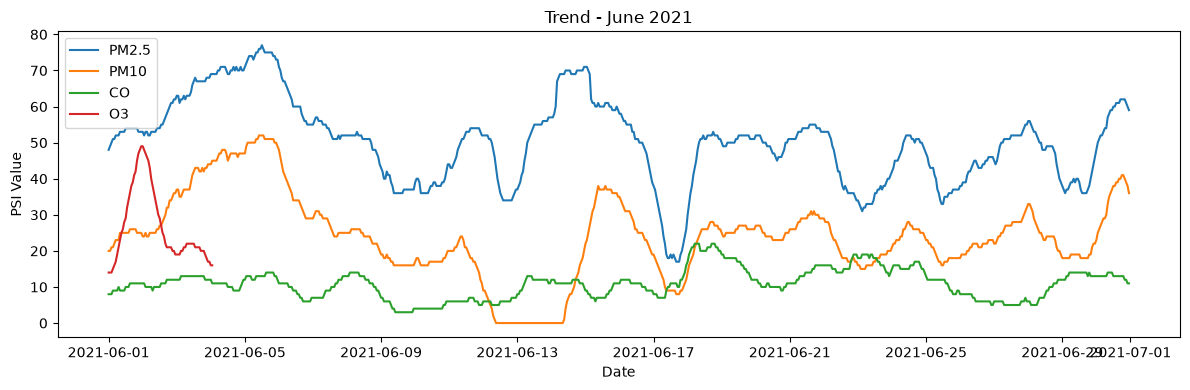

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "06-jogja-jun-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the June data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - June 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

**In June 2021, PM2.5 was still the highest most of the month (17–77), O3 only had data for the first week and then disappeared (missing for the rest of the month), while PM10 and CO stayed lower and moved together throughout.**

##### <span style="color:blue">**2. Boxplot**</span>

Data source: 06-jogja-jun-2021.csv


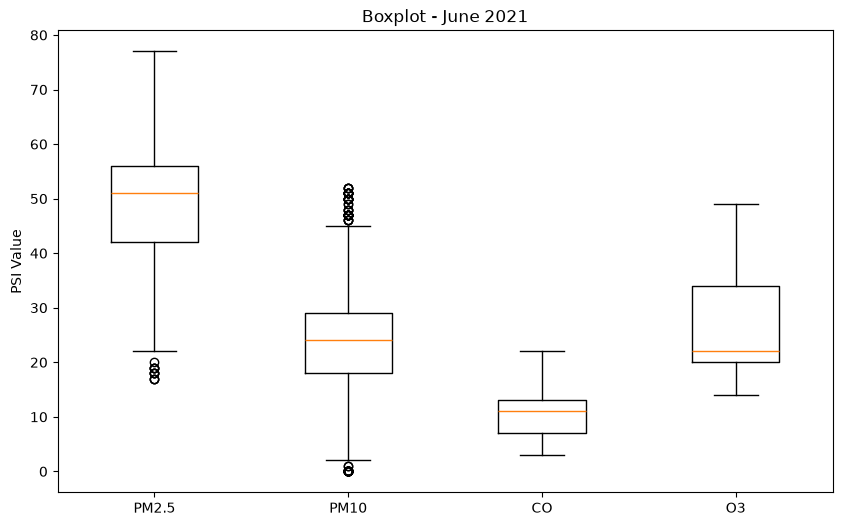

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "06-jogja-jun-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col].dropna() for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - June 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

**In June 2021, PM2.5 had the highest median (51) with some low outliers, PM10 had outliers on both sides, CO and O3 had no outliers, and O3 was based on only a few data points.**

##### <span style="color:blue">**3. Bar Chart**</span>

Data source: 06-jogja-jun-2021.csv


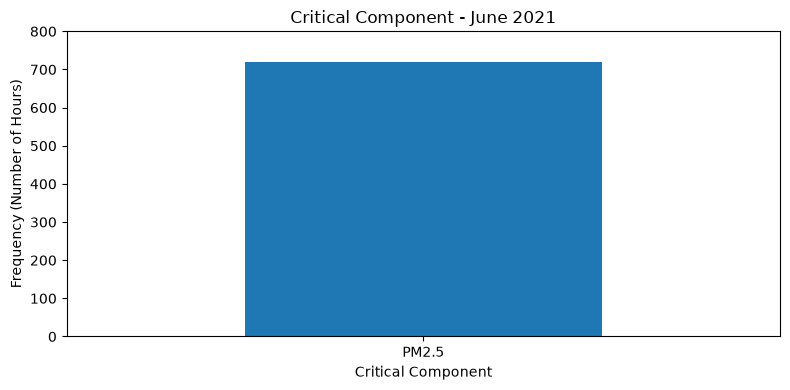

Critical Component
PM2.5    720
Name: count, dtype: int64

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "06-jogja-jun-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

# Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - June 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts()

**In June 2021, PM2.5 was the critical component for all 720 hours of the month, as no other pollutant was ever the main driver, the same pattern as March.**

Data source: 06-jogja-jun-2021.csv


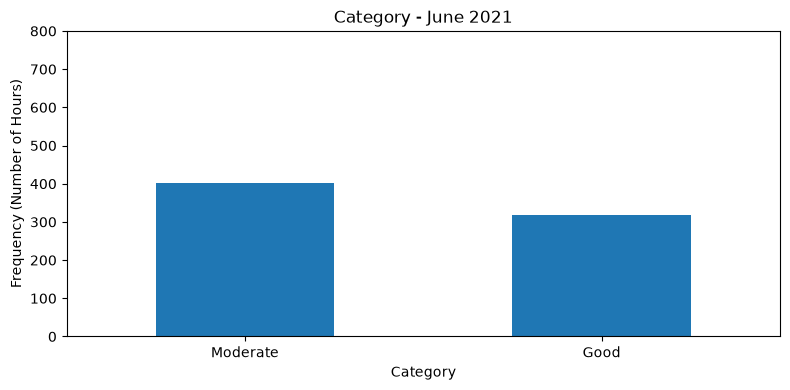

Category
Moderate    403
Good        317
Name: count, dtype: int64

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "06-jogja-jun-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df["Category"].value_counts().plot(kind="bar")
plt.title("Category - June 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category